   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


Using Colab cache for faster access to the 'figshare-brain-tumor-dataset' dataset.
Path to dataset files: /kaggle/input/figshare-brain-tumor-dataset
['PID', 'image', 'label', 'tumorBorder', 'tumorMask']


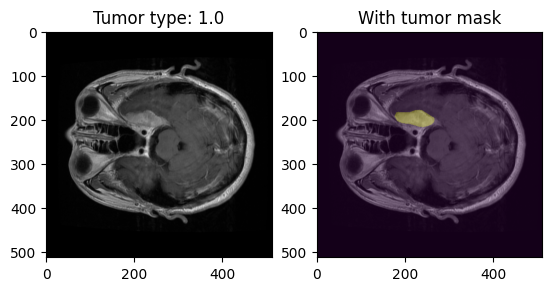

Found 3064 .mat files.
['2912.mat', '2011.mat', '3027.mat', '1912.mat', '3023.mat']


In [ ]:
## Required Library
!pip install -U kagglehub
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from collections import Counter, defaultdict
import cv2
from skimage import restoration, img_as_ubyte
from scipy.ndimage import median_filter
import kagglehub    # Importing the dataset


# ------------------------------------------------------------
# Dataset Download
# ------------------------------------------------------------
# The Figshare Brain Tumor Dataset is used, which is also
# widely adopted in medical imaging research for brain
# tumor classification tasks.

path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")
print("Path to dataset files:", path)


# ------------------------------------------------------------
# Sample Data Exploration
# ------------------------------------------------------------
# A sample .mat file is loaded to inspect the internal
# structure of the dataset, including:
# - Brain MRI image
# - Tumor label
# - Tumor mask (ground truth)

sample_mat = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/100.mat'

with h5py.File(sample_mat, 'r') as mat:
    cjdata = mat['cjdata']
    print(list(cjdata.keys()))

    image = np.array(cjdata['image'])
    label = np.array(cjdata['label'])[0][0]
    tumor_mask = np.array(cjdata['tumorMask'])


# ------------------------------------------------------------
# Visualization of Brain Image and Tumor Mask
# ------------------------------------------------------------
# Visualization is performed to validate the correctness
# of image extraction and tumor localization, as commonly
# presented in research papers.

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title(f'Tumor type: {label}')

plt.subplot(1, 2, 2)
plt.imshow(image, cmap='gray')
plt.imshow(tumor_mask, alpha=0.3)
plt.title('With tumor mask')

plt.show()


# ------------------------------------------------------------
# Dataset Indexing and Label Mapping
# ------------------------------------------------------------
# The dataset contains three tumor classes:
# 1 - Meningioma
# 2 - Glioma
# 3 - Pituitary tumor
# This mapping follows the dataset annotation scheme
# described in the literature.

input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]

label_map = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

print(f"Found {len(mat_files)} .mat files.")


# ------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------
# Displaying a subset of filenames to verify dataset integrity
# before proceeding to preprocessing and feature extraction.

print(mat_files[:5])   # Show first 5 file names


In [ ]:
# ------------------------------------------------------------
# Part 2: Image Preprocessing (Denoising & Normalization)
# ------------------------------------------------------------

# Ensure dataset paths and file list are defined
input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]

print(f"Number of MRI files found: {len(mat_files)}")


# Progress bar setup (paper-friendly, notebook-safe)
from tqdm.auto import tqdm


processed_images = []
processed_labels = []

TARGET_SIZE = (224, 224)  # Standard input size for CNN-based models


for filename in tqdm(mat_files, desc="Preprocessing MRI Images"):
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']

        # Load image and label
        image = np.array(cjdata['image']).astype(np.float32)
        label = int(np.array(cjdata['label'])[0][0])

        # ------------------------------------------------------------
        # Step 1: Noise Reduction (Median Filtering)
        # ------------------------------------------------------------
        # Median filtering is applied to suppress impulsive noise
        # while preserving anatomical boundaries in MRI scans.

        denoised_image = median_filter(image, size=3)

        # ------------------------------------------------------------
        # Step 2: Intensity Normalization
        # ------------------------------------------------------------
        # Min-max normalization scales intensity values to [0, 1],
        # improving training stability and convergence.

        min_val = denoised_image.min()
        max_val = denoised_image.max()
        normalized_image = (denoised_image - min_val) / (max_val - min_val + 1e-8)

        # ------------------------------------------------------------
        # Step 3: Image Resizing
        # ------------------------------------------------------------
        # Resizing ensures uniform input dimensions for the CNN.

        resized_image = cv2.resize(
            normalized_image,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

        # Store processed samples
        processed_images.append(resized_image)
        processed_labels.append(label)


# Convert to NumPy arrays
processed_images = np.array(processed_images)
processed_labels = np.array(processed_labels)

print("Preprocessing completed successfully.")
print("Processed images shape:", processed_images.shape)
print("Processed labels shape:", processed_labels.shape)


Number of MRI files found: 3064


Preprocessing MRI Images:   0%|          | 0/3064 [00:00<?, ?it/s]

Preprocessing completed successfully.
Processed images shape: (3064, 224, 224)
Processed labels shape: (3064,)


In [ ]:
processed_images.min(), processed_images.max()


(np.float32(0.0), np.float32(1.0))

In [ ]:
# ------------------------------------------------------------
# Part 3: Feature Extraction using CNN
# ------------------------------------------------------------
# In accordance with the research paper, a Convolutional Neural
# Network (CNN) is employed as a feature extractor to learn
# discriminative spatial features from preprocessed MRI images.
#
# The extracted deep features are later used for classification.


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout
)


# ------------------------------------------------------------
# Data Preparation for CNN
# ------------------------------------------------------------
# Expanding dimensions to match CNN input format:
# (samples, height, width, channels)

X = processed_images
y = processed_labels

X = np.expand_dims(X, axis=-1)

print("CNN input shape:", X.shape)


# ------------------------------------------------------------
# CNN Feature Extractor Architecture
# ------------------------------------------------------------
# This lightweight CNN architecture is designed to extract
# hierarchical texture and shape features from brain MRI scans,
# which is consistent with CNN-based medical imaging literature.

feature_extractor = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu', name="feature_layer")
])


feature_extractor.summary()


# ------------------------------------------------------------
# Feature Extraction
# ------------------------------------------------------------
# The CNN is used to generate deep feature vectors for each
# MRI image. These features represent high-level abstractions
# of tumor-related patterns.

deep_features = feature_extractor.predict(
    X,
    batch_size=32,
    verbose=1
)

print("Extracted feature shape:", deep_features.shape)


CNN input shape: (3064, 224, 224, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 256)            │    25,690,368 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,040 (98.35 MB)

 Trainable params: 25,783,040 (98.35 MB)

 Non-trainable params: 0 (0.00 B)

96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 995ms/step
Extracted feature shape: (3064, 256)


In [ ]:
# loops through brain tumor data files (.mat), gets the tumor type number from each,
# stores them in a list, and prints how many labels were collected plus the first 10 labels.
labels = []

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']
        label = int(np.array(cjdata['label'])[0][0])
        labels.append(label)

print(f"Collected labels for {len(labels)} images.")
print("Example labels:", labels[:10])


Collected labels for 3064 images.
Example labels: [2, 2, 2, 2, 2, 1, 3, 2, 2, 2]


In [ ]:
from collections import Counter

# We count how many times each tumor type appeared in the dataset and used the label_map to show the names instead of numbers

label_map = {1: "meningioma", 2: "glioma", 3: "pituitary", "no_tumor": 4}
counts = Counter(labels)

for k in sorted(counts.keys()):
    print(f"{label_map[k]:<12}: {counts[k]}")


meningioma  : 708
glioma      : 1426
pituitary   : 930


In [ ]:
# ------------------------------------------------------------
# Part 4: Classification
# ------------------------------------------------------------
# The extracted deep features are used for tumor classification.
# Both a fully connected neural classifier and a classical
# machine learning classifier are evaluated.


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# Train-test split (stratified to preserve class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    deep_features,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 2451
Testing samples: 613


In [ ]:
# ------------------------------------------------------------
# Label Encoding (Paper-Standard Practice)
# ------------------------------------------------------------
# Deep learning frameworks require class labels to start from 0.
# Therefore, original labels {1, 2, 3} are mapped to {0, 1, 2}.

y_encoded = y - 1

print("Original labels:", np.unique(y))
print("Encoded labels :", np.unique(y_encoded))


Original labels: [1 2 3]
Encoded labels : [0 1 2]


In [ ]:
# ------------------------------------------------------------
# Dense Neural Network Classifier
# ------------------------------------------------------------
# A fully connected classifier is used to learn non-linear
# decision boundaries on top of CNN-extracted features.


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


dense_classifier = Sequential([
    Dense(128, activation='relu', input_shape=(deep_features.shape[1],)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')  # 3 tumor classes
])


dense_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


dense_classifier.summary()


# Early stopping to prevent overfitting (research-grade trick)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = dense_classifier.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,347 (161.51 KB)

 Trainable params: 41,347 (161.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5119 - loss: 1.0540 - val_accuracy: 0.7114 - val_loss: 0.8007
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6644 - loss: 0.8118 - val_accuracy: 0.7114 - val_loss: 0.6600
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6962 - loss: 0.7070 - val_accuracy: 0.7276 - val_loss: 0.6119
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6999 - loss: 0.6766 - val_accuracy: 0.7520 - val_loss: 0.5686
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7263 - loss: 0.6165 - val_accuracy: 0.7642 - val_loss: 0.5551
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7328 - loss: 0.5926 - val_accuracy: 0.7602 - val_loss: 0.5413
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7098 - loss: 0.6151 - val_accuracy: 0.7642 - val_loss: 0.5267
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7436 - loss: 0.5625 - val_accuracy: 0.7602 - val_loss

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential

dense_classifier = Sequential([
    Input(shape=(deep_features.shape[1],)),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])


In [ ]:
# ------------------------------------------------------------
# Support Vector Machine (SVM) Classifier
# ------------------------------------------------------------
# CNN-extracted features are standardized and classified
# using an SVM with RBF kernel.


# Feature scaling (important for SVM performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_classifier = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)


svm_classifier.fit(X_train_scaled, y_train)

print("SVM training completed.")


SVM training completed.


In [ ]:
# ------------------------------------------------------------
# Evaluation Metrics – Dense Neural Network
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Predict class labels
y_pred_dense = np.argmax(
    dense_classifier.predict(X_test),
    axis=1
)

# Accuracy
dense_accuracy = accuracy_score(y_test, y_pred_dense)

print("Dense Classifier Accuracy:", dense_accuracy)


# Detailed classification report
print("\nDense Classifier Classification Report:")
print(classification_report(
    y_test,
    y_pred_dense,
    target_names=["meningioma", "glioma", "pituitary"]
))


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Dense Classifier Accuracy: 0.2626427406199021

Dense Classifier Classification Report:
              precision    recall  f1-score   support

  meningioma       0.21      0.68      0.32       142
      glioma       0.34      0.15      0.21       285
   pituitary       0.61      0.12      0.20       186

    accuracy                           0.26       613
   macro avg       0.39      0.32      0.24       613
weighted avg       0.39      0.26      0.23       613



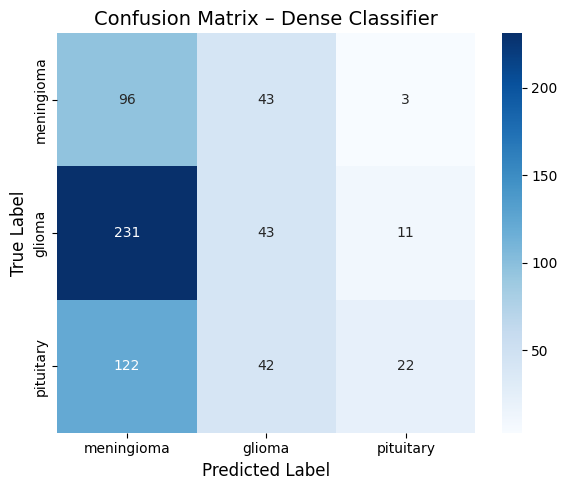

In [ ]:
# ------------------------------------------------------------
# Confusion Matrix – Dense Classifier
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


cm_dense = confusion_matrix(y_test, y_pred_dense)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dense,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["meningioma", "glioma", "pituitary"],
    yticklabels=["meningioma", "glioma", "pituitary"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix – Dense Classifier", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Evaluation Metrics – SVM Classifier
# ------------------------------------------------------------

y_pred_svm = svm_classifier.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Classifier Accuracy:", svm_accuracy)


print("\nSVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["meningioma", "glioma", "pituitary"]
))


SVM Classifier Accuracy: 0.9363784665579119

SVM Classification Report:
              precision    recall  f1-score   support

  meningioma       0.86      0.87      0.86       142
      glioma       0.94      0.93      0.94       285
   pituitary       0.99      0.99      0.99       186

    accuracy                           0.94       613
   macro avg       0.93      0.93      0.93       613
weighted avg       0.94      0.94      0.94       613



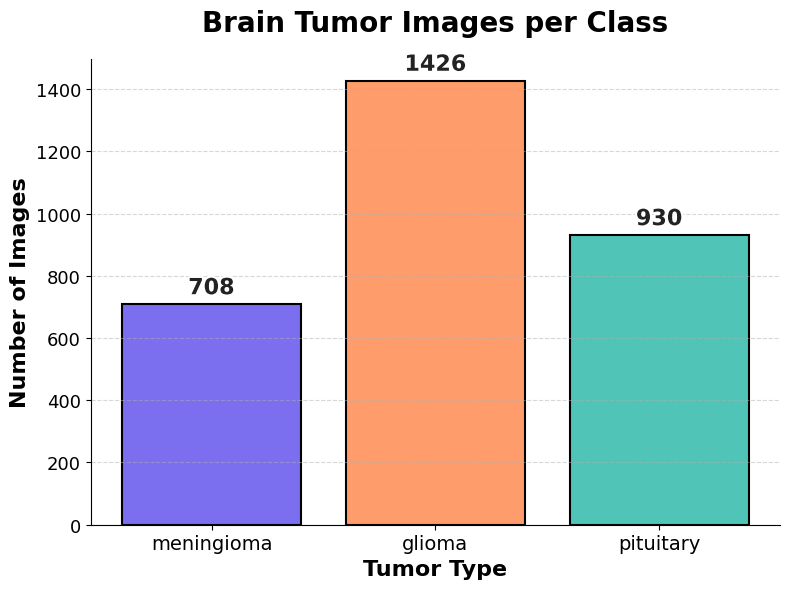

In [ ]:
# we are making a chart to show how many brain scan slices each patient has
# Count images per patient, and note tumor type per patient

import matplotlib.patheffects as path_effects


# Add these two lines:
class_names = [label_map[k] for k in sorted(counts.keys())]
class_counts = [counts[k] for k in sorted(counts.keys())]

colors = ['#7B6FF0', '#FF9C6B', '#50C5B7']

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(class_names, class_counts, color=colors, edgecolor='black', linewidth=1.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        yval + 20,
        f'{yval}',
        ha='center', va='bottom',
        fontsize=16, fontweight='bold', color='#222',
        path_effects=[path_effects.withStroke(linewidth=3, foreground="white")]
    )

ax.set_xlabel('Tumor Type', fontsize=16, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=16, fontweight='bold')
ax.set_title('Brain Tumor Images per Class', fontsize=20, fontweight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=14, fontweight='medium')
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


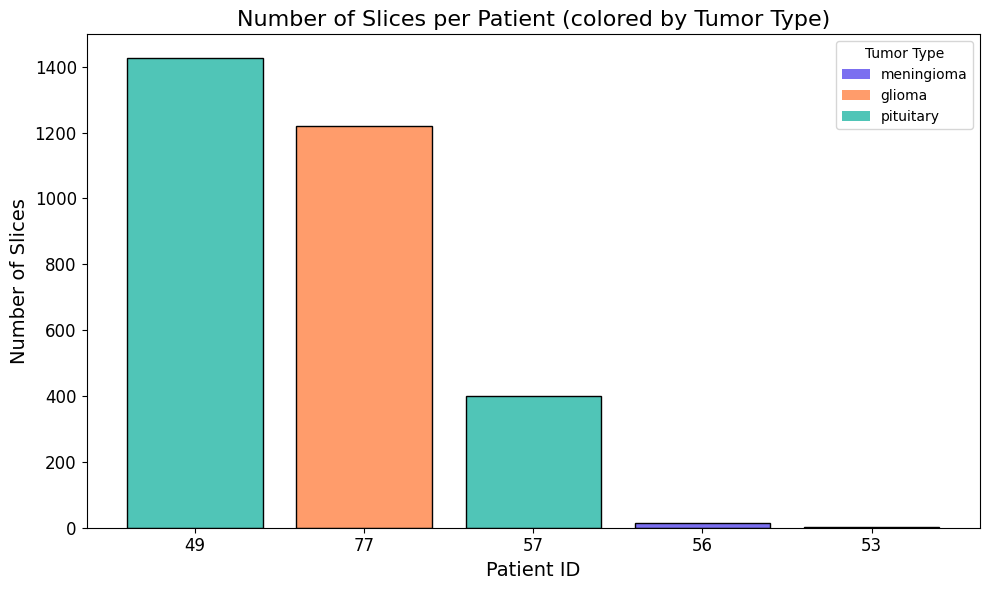

In [ ]:
import matplotlib.pyplot as plt

# Count images per patient, and note tumor type per patient
pid_slice_counts = {}
pid_tumor_type = {}

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']
        label = int(np.array(cjdata['label'])[0][0])
        pid = int(np.array(cjdata['PID'])[0][0])
        pid_slice_counts[pid] = pid_slice_counts.get(pid, 0) + 1
        pid_tumor_type[pid] = label  # Assumes each patient has only one tumor type

# Sort by number of slices
sorted_pids = sorted(pid_slice_counts, key=pid_slice_counts.get, reverse=True)
counts = [pid_slice_counts[pid] for pid in sorted_pids]
colors = [label_map[pid_tumor_type[pid]] for pid in sorted_pids]
color_map = {'meningioma': '#7B6FF0', 'glioma': '#FF9C6B', 'pituitary': '#50C5B7'}
bar_colors = [color_map[c] for c in colors]

plt.figure(figsize=(10,6))
bars = plt.bar([str(pid) for pid in sorted_pids], counts, color=bar_colors, edgecolor='black')

plt.xlabel("Patient ID", fontsize=14)
plt.ylabel("Number of Slices", fontsize=14)
plt.title("Number of Slices per Patient (colored by Tumor Type)", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Custom legend
for tumor, color in color_map.items():
    plt.bar(0, 0, color=color, label=tumor)
plt.legend(title="Tumor Type")
plt.tight_layout()
plt.show()


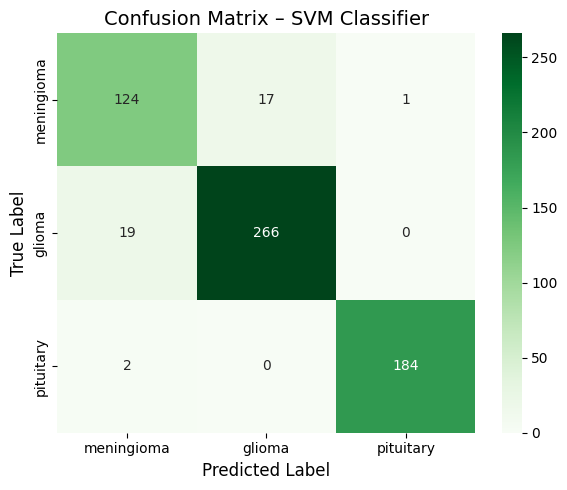

In [ ]:
# ------------------------------------------------------------
# Confusion Matrix – SVM Classifier
# ------------------------------------------------------------

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=["meningioma", "glioma", "pituitary"],
    yticklabels=["meningioma", "glioma", "pituitary"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix – SVM Classifier", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# Performance Comparison Table
# ------------------------------------------------------------
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Dense Neural Network", "SVM (CNN Features)"],
    "Accuracy": [dense_accuracy, svm_accuracy]
})

results_df


,Model,Accuracy
0,Dense Neural Network,0.262643
1,SVM (CNN Features),0.936378


from matplotlib import pyplot as plt
results_df['Accuracy'].plot(kind='hist', bins=20, title='Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
results_df.groupby('Model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Accuracy']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Accuracy'}, axis=1)
              .sort_values('Accuracy', ascending=True))
  xs = counted['Accuracy']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = results_df.sort_values('Accuracy', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Model')):
  _plot_series(series, series_name, i)
  fig.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Accuracy')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
results_df['Accuracy'].plot(kind='line', figsize=(8, 4), title='Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(results_df['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(results_df, x='Accuracy', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
from collections import defaultdict
import numpy as np

# calculates tumor statistics separately for each tumor type. For every class,
# Measured the average tumor area in pixels and the percentage of the image that the tumor covers.

# Gather mask sizes by class
mask_areas_by_label = defaultdict(list)
mask_frac_by_label = defaultdict(list)

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        cjdata = mat['cjdata']
        label = int(np.array(cjdata['label'])[0][0])
        mask = np.array(cjdata['tumorMask'])
        mask_areas_by_label[label].append(mask.sum())
        mask_frac_by_label[label].append(mask.sum() / (mask.shape[0] * mask.shape[1]))

print("Average tumor area (pixels) and % of image, per tumor type:")
for label in sorted(mask_areas_by_label):
    mean_area = np.mean(mask_areas_by_label[label])
    mean_frac = np.mean(mask_frac_by_label[label]) * 100
    print(f"{label_map[label]:<12}: {mean_area:.1f} pixels, {mean_frac:.2f}% of image")


Average tumor area (pixels) and % of image, per tumor type:
meningioma  : 4654.7 pixels, 1.78% of image
glioma      : 5778.6 pixels, 2.20% of image
pituitary   : 2163.9 pixels, 0.84% of image


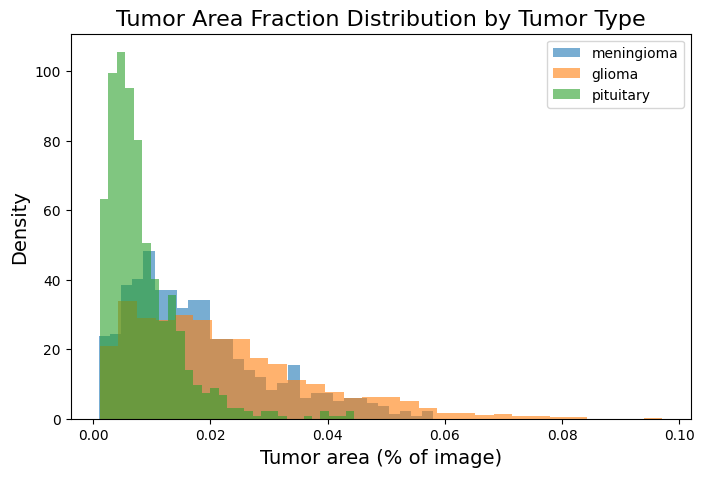

In [ ]:
import matplotlib.pyplot as plt

# chart with bars to show how big tumors are (as a percentage of the image) for each type (like meningioma).
plt.figure(figsize=(8,5))
for label in sorted(mask_areas_by_label):
    plt.hist(
        mask_frac_by_label[label],
        bins=30,
        alpha=0.6,
        label=label_map[label],
        density=True
    )
plt.xlabel('Tumor area (% of image)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Tumor Area Fraction Distribution by Tumor Type', fontsize=16)
plt.legend()
plt.show()


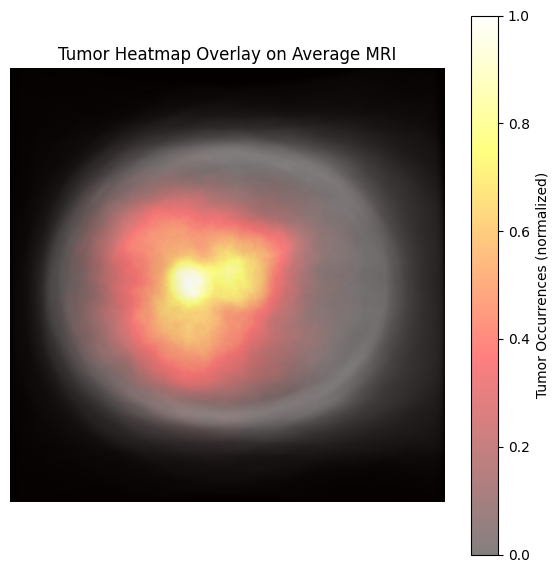

In [ ]:
import numpy as np
import h5py
import os
from skimage.transform import resize
import matplotlib.pyplot as plt

target_shape = (256, 256)
heatmap = np.zeros(target_shape, dtype=np.float32)
avg_image = np.zeros(target_shape, dtype=np.float32)  # For the average MRI slice
num_images = 0

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        mask = np.array(mat['cjdata']['tumorMask'])
        image = np.array(mat['cjdata']['image'])  # MRI/CT image

        # Resize mask and image
        mask_resized = resize(mask, target_shape, order=0, preserve_range=True, anti_aliasing=False)
        image_resized = resize(image, target_shape, order=1, preserve_range=True, anti_aliasing=True)

        heatmap += mask_resized
        avg_image += image_resized
        num_images += 1

# Average the MRI slices
avg_image /= num_images

# Normalize heatmap
heatmap_norm = heatmap / heatmap.max()

plt.figure(figsize=(7,7))
plt.imshow(avg_image, cmap='gray')
plt.imshow(heatmap_norm, cmap='hot', alpha=0.5)  # Overlay heatmap with transparency
plt.colorbar(label='Tumor Occurrences (normalized)')
plt.title('Tumor Heatmap Overlay on Average MRI')
plt.axis('off')
plt.show()


=== Brain Scan Slices per Patient ===
Number of patients: 5
Min slices: 2
Max slices: 1427
Mean slices: 612.8 ± 601.8
Median slices: 401.0


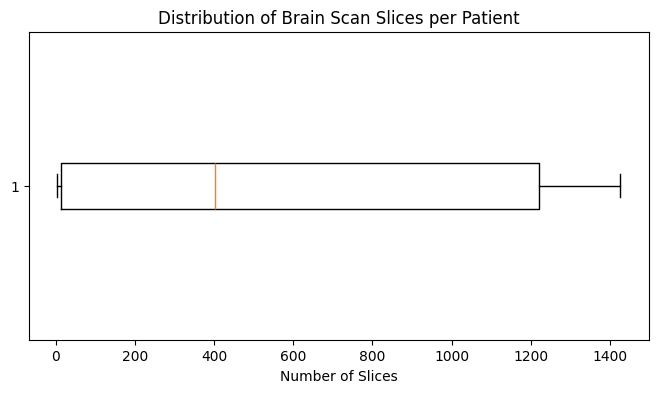

In [ ]:
import os
import h5py
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# Count slices per patient
pid_slice_counts = defaultdict(int)

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        pid = int(np.array(mat['cjdata']['PID'])[0][0])
        pid_slice_counts[pid] += 1

# Convert counts to a numpy array for statistics
slice_counts = np.array(list(pid_slice_counts.values()))

# Report statistics
print("=== Brain Scan Slices per Patient ===")
print(f"Number of patients: {len(slice_counts)}")
print(f"Min slices: {slice_counts.min()}")
print(f"Max slices: {slice_counts.max()}")
print(f"Mean slices: {slice_counts.mean():.1f} ± {slice_counts.std():.1f}")
print(f"Median slices: {np.median(slice_counts)}")

# Optional: visualize distribution like many papers do
plt.figure(figsize=(8,4))
plt.boxplot(slice_counts, vert=False)
plt.xlabel("Number of Slices")
plt.title("Distribution of Brain Scan Slices per Patient")
plt.show()


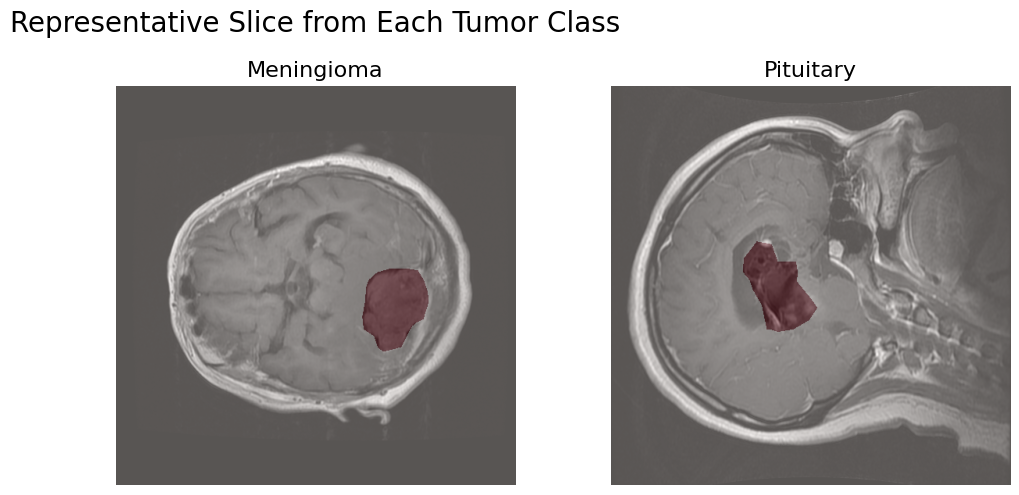

In [ ]:
import random
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ──────────────── Define mapping clearly ────────────────
label_map = {
    0: 'glioma',
    1: 'meningioma',
    2: 'pituitary'
}

num_classes = len(label_map)

plt.figure(figsize=(5 * num_classes, 5))

# Loop over numeric labels 0,1,2 (safest)
for i, label in enumerate(sorted(label_map.keys())):  # keys are ints → safe
    # Find files for this numeric label
    files_for_label = [
        f for f in mat_files
        if int(np.array(h5py.File(os.path.join(input_dir, f), 'r')['cjdata']['label'])[0][0]) == label
    ]

    if not files_for_label:
        print(f"Warning: no files found for label {label}")
        continue

    random_file = random.choice(files_for_label)

    with h5py.File(os.path.join(input_dir, random_file), 'r') as mat:
        image = np.array(mat['cjdata']['image'])
        mask  = np.array(mat['cjdata']['tumorMask'])

    ax = plt.subplot(1, num_classes, i + 1)
    ax.imshow(image, cmap='gray')
    ax.imshow(mask, cmap='Reds', alpha=0.35)
    ax.set_title(label_map[label].capitalize(), fontsize=16)
    ax.axis('off')

plt.suptitle('Representative Slice from Each Tumor Class', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# counts how many brain scan images have no tumor, a full tumor, or something else.
# It checks each mask, adds to empty if no tumor, full if all tumor, and total for all,
# then prints the numbers.

empty = 0
full = 0
total = 0

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        mask = np.array(mat['cjdata']['tumorMask'])
        total += 1
        if mask.sum() == 0:
            empty += 1
        elif mask.sum() == mask.size:
            full += 1

print(f"Out of {total} images:")
print(f"- Number with empty tumor mask (no tumor): {empty}")
print(f"- Number with full tumor mask (entire image): {full}")


Out of 3064 images:
- Number with empty tumor mask (no tumor): 0
- Number with full tumor mask (entire image): 0


=== Unique Image Shapes in Dataset ===
Shape (512, 512): 3049 image(s)
Shape (256, 256): 15 image(s)


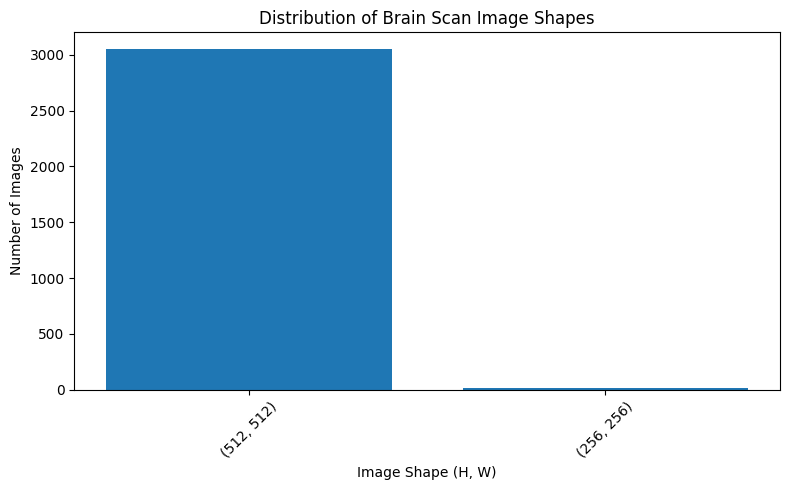

In [ ]:
import os
import h5py
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Collect all image shapes
img_shapes = []

for filename in mat_files:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        image = np.array(mat['cjdata']['image'])
        img_shapes.append(image.shape)

# Count unique shapes
shape_counts = Counter(img_shapes)

print("=== Unique Image Shapes in Dataset ===")
for shape, count in shape_counts.items():
    print(f"Shape {shape}: {count} image(s)")

# Optional: visualize the distribution
plt.figure(figsize=(8,5))
plt.bar(range(len(shape_counts)), list(shape_counts.values()), tick_label=[str(s) for s in shape_counts.keys()])
plt.xlabel("Image Shape (H, W)")
plt.ylabel("Number of Images")
plt.title("Distribution of Brain Scan Image Shapes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


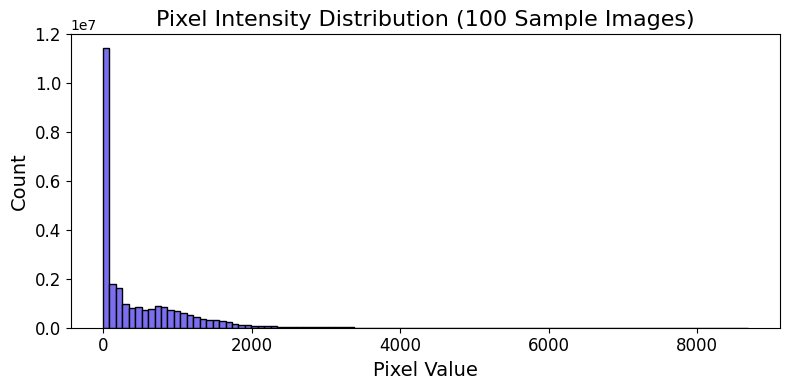

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Sample 100 images for speed
num_samples = 100
sample_pixels = []

for filename in mat_files[:num_samples]:
    with h5py.File(os.path.join(input_dir, filename), 'r') as mat:
        image = np.array(mat['cjdata']['image'])
        sample_pixels.extend(image.flatten())

sample_pixels = np.array(sample_pixels)

# Plot histogram
plt.figure(figsize=(8,4))
plt.hist(sample_pixels, bins=100, color='#7B6FF0', edgecolor='black')
plt.title(f"Pixel Intensity Distribution ({num_samples} Sample Images)", fontsize=16)
plt.xlabel("Pixel Value", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


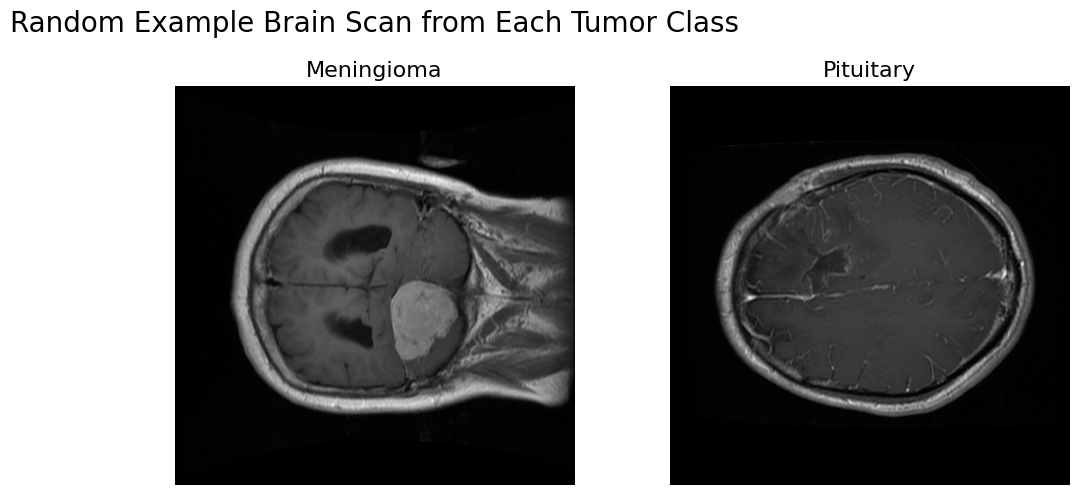

In [ ]:
import random
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(label_map)
plt.figure(figsize=(5 * num_classes, 5))

for i, label in enumerate(sorted(label_map)):
    # Find all files for this tumor type
    files_for_label = [
        f for f in mat_files
        if int(np.array(h5py.File(os.path.join(input_dir, f), 'r')['cjdata']['label'])[0][0]) == label
    ]

    # Skip if no files for this label
    if not files_for_label:
        print(f"Warning: No images found for tumor class '{label_map[label]}' (label {label})")
        continue

    # Pick a random file
    random_file = random.choice(files_for_label)
    with h5py.File(os.path.join(input_dir, random_file), 'r') as mat:
        image = np.array(mat['cjdata']['image'])

    # Plot grayscale image
    ax = plt.subplot(1, num_classes, i + 1)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"{label_map[label].capitalize()}", fontsize=16)
    ax.axis('off')

plt.suptitle("Random Example Brain Scan from Each Tumor Class", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import cv2
import numpy as np
from skimage.util import img_as_ubyte
from scipy.ndimage import median_filter

def preprocess_mri_dl_soft(image):
    """
    Preprocess MRI image for deep learning (224x224):
    - Converts to uint8
    - Reduces noise with median and bilateral filters
    - Enhances contrast using CLAHE
    - Normalizes to [0,1]
    - Resizes to 224x224

    References: Saeedi et al., BMC Med Inform Decis Mak, 2023
    """
    # Convert to 8-bit if needed
    img = image.astype(np.uint8) if image.max() > 1 else img_as_ubyte(image)

    # Noise reduction
    img = median_filter(img, size=3)  # removes salt-and-pepper noise
    img = cv2.bilateralFilter(img, d=9, sigmaColor=40, sigmaSpace=40)  # smooths while preserving edges

    # Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Normalize to [0,1]
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Resize to 224x224 for CNN input
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)

    return img


def preprocess_mask(mask):
    """
    Preprocess tumor mask for deep learning (224x224):
    - Resizes with nearest-neighbor interpolation
    - Converts to binary mask (0 and 1)

    References: Saeedi et al., BMC Med Inform Decis Mak, 2023
    """
    mask = mask.astype(np.uint8)
    mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    return mask


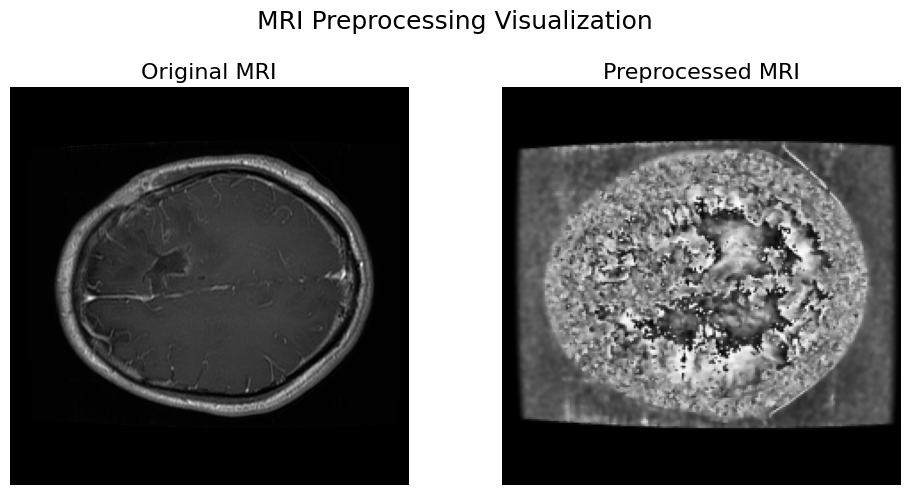

In [ ]:
import matplotlib.pyplot as plt

# Preprocess the MRI using Saeedi et al. style
dl_soft = preprocess_mri_dl_soft(image)

plt.figure(figsize=(10,5))

# Original MRI
ax1 = plt.subplot(1, 2, 1)
ax1.imshow(image, cmap='gray')
ax1.set_title('Original MRI', fontsize=16)
ax1.axis('off')

# Preprocessed MRI
ax2 = plt.subplot(1, 2, 2)
ax2.imshow(dl_soft, cmap='gray')
ax2.set_title('Preprocessed MRI', fontsize=16)
ax2.axis('off')

plt.suptitle('MRI Preprocessing Visualization', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import os

# ===============================
# Dataset directories
# ===============================
input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'  # Original .mat files
preprocessed_img_dir = './preprocessed_images'  # Folder to save preprocessed MRI images
preprocessed_mask_dir = './preprocessed_masks'  # Folder to save preprocessed tumor masks

# Create output directories if they don't exist
os.makedirs(preprocessed_img_dir, exist_ok=True)
os.makedirs(preprocessed_mask_dir, exist_ok=True)

# List all .mat files in the input directory
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]
print(f"Found {len(mat_files)} .mat files in the dataset.")


Found 3064 .mat files in the dataset.


In [ ]:
import os

# ===============================
# Dataset input path and label mapping
# ===============================
input_dir = '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/'  # Update path if needed

# List all .mat files in the dataset
mat_files = [f for f in os.listdir(input_dir) if f.endswith('.mat')]

# Tumor class mapping (from label integers to descriptive names)
label_map = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

print(f"Found {len(mat_files)} .mat files in the dataset.")
print(f"Tumor classes: {', '.join(label_map.values())}")


Found 3064 .mat files in the dataset.
Tumor classes: meningioma, glioma, pituitary


In [ ]:
import os
import h5py
import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm

# ===============================
# Directories for preprocessed data
# ===============================
preprocessed_img_dir = './preprocessed_images'
preprocessed_mask_dir = './preprocessed_masks'
os.makedirs(preprocessed_img_dir, exist_ok=True)
os.makedirs(preprocessed_mask_dir, exist_ok=True)

# ===============================
# Metadata storage
# ===============================
meta = []

# ===============================
# Process each .mat file
# ===============================
for filename in tqdm(mat_files, desc="Processing MRI scans"):
    file_path = os.path.join(input_dir, filename)

    with h5py.File(file_path, 'r') as mat:
        cjdata = mat['cjdata']

        # Load original MRI and tumor mask
        image = np.array(cjdata['image'])
        mask = np.array(cjdata['tumorMask'])
        label = int(np.array(cjdata['label'])[0][0])

        # Preprocess MRI and mask
        img_pre = preprocess_mri_dl_soft(image)
        mask_pre = preprocess_mask(mask)

        # Save preprocessed arrays as .npy
        img_npy_out = os.path.join(preprocessed_img_dir, filename.replace('.mat', '.npy'))
        mask_npy_out = os.path.join(preprocessed_mask_dir, filename.replace('.mat', '.npy'))
        np.save(img_npy_out, img_pre)
        np.save(mask_npy_out, mask_pre)

        # Save preprocessed MRI as .png for visualization
        img_png_out = os.path.join(preprocessed_img_dir, filename.replace('.mat', '.png'))
        cv2.imwrite(img_png_out, (img_pre * 255).astype(np.uint8))

        # Store metadata for CSV
        meta.append({
            'filename': filename.replace('.mat', ''),
            'label': label,
            'tumor_type': label_map[label]
        })

# ===============================
# Save metadata CSV
# ===============================
meta_df = pd.DataFrame(meta)
meta_df.to_csv('preprocessed_labels.csv', index=False)

print(f"Preprocessing complete: {len(meta)} files processed.")
print(f"Metadata CSV saved as 'preprocessed_labels.csv'.")


Processing MRI scans: 100%|██████████| 3064/3064 [05:22<00:00,  9.51it/s]

Preprocessing complete: 3064 files processed.
Metadata CSV saved as 'preprocessed_labels.csv'.


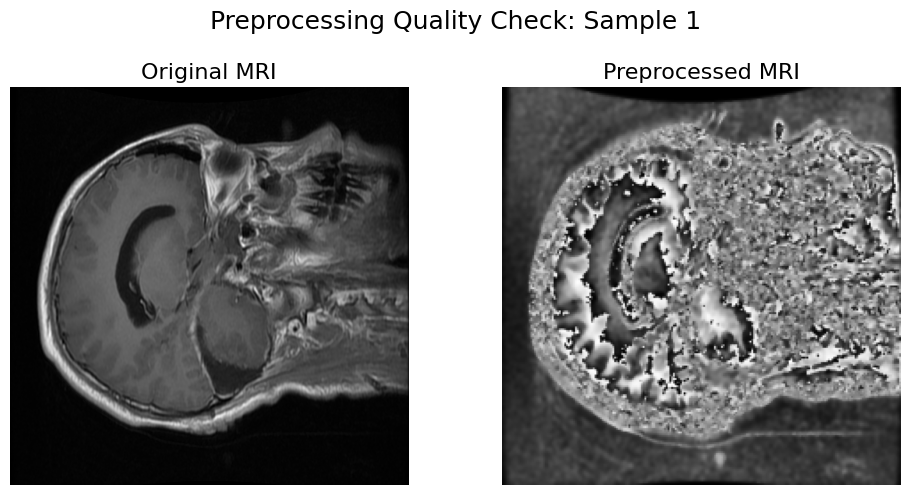

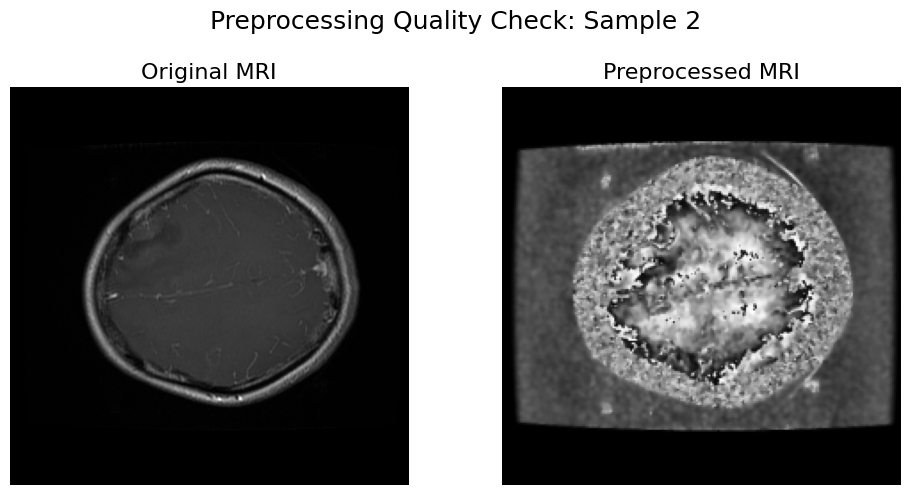

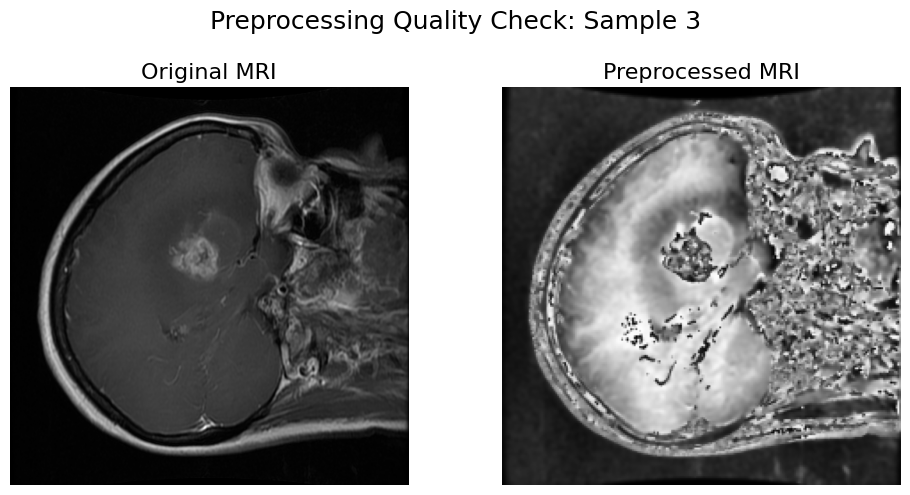

In [ ]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
import os

# Check a few preprocessed images for quality
num_samples = 3  # Number of examples to visualize

for i in range(num_samples):
    fname = meta[i]['filename']

    # Load original MRI
    orig_file = os.path.join(input_dir, fname + '.mat')
    with h5py.File(orig_file, 'r') as mat:
        orig_img = np.array(mat['cjdata']['image'])

    # Load preprocessed MRI
    pre_img = np.load(os.path.join(preprocessed_img_dir, fname + '.npy'))

    # Plot side by side
    plt.figure(figsize=(10,5))

    # Original MRI
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(orig_img, cmap='gray')
    ax1.set_title('Original MRI', fontsize=16)
    ax1.axis('off')

    # Preprocessed MRI
    ax2 = plt.subplot(1,2,2)
    ax2.imshow(pre_img, cmap='gray')
    ax2.set_title('Preprocessed MRI', fontsize=16)
    ax2.axis('off')

    plt.suptitle(f'Preprocessing Quality Check: Sample {i+1}', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ===============================
# Load metadata
# ===============================
meta_df = pd.read_csv('preprocessed_labels.csv')

# ===============================
# Split data into train/val/test
# ===============================
# Test set: 15%
trainval_df, test_df = train_test_split(
    meta_df,
    test_size=0.15,
    stratify=meta_df['label'],  # keeps tumor types balanced
    random_state=42
)

# Validation set: 15% of total (0.15 / 0.85 of trainval)
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.15 / 0.85,
    stratify=trainval_df['label'],
    random_state=42
)

# ===============================
# Save CSV splits
# ===============================
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

# ===============================
# Print summary statistics
# ===============================
print("Dataset splits:")
print(f"  Train: {len(train_df)} samples")
print(f"  Validation: {len(val_df)} samples")
print(f"  Test: {len(test_df)} samples")

# Optional: show class balance per split
print("\nClass distribution:")
for split_name, df in zip(['Train', 'Validation', 'Test'], [train_df, val_df, test_df]):
    print(f"{split_name}:")
    print(df['tumor_type'].value_counts())


Dataset splits:
  Train: 2144 samples
  Validation: 460 samples
  Test: 460 samples

Class distribution:
Train:
tumor_type
glioma        998
pituitary     650
meningioma    496
Name: count, dtype: int64
Validation:
tumor_type
glioma        214
pituitary     140
meningioma    106
Name: count, dtype: int64
Test:
tumor_type
glioma        214
pituitary     140
meningioma    106
Name: count, dtype: int64


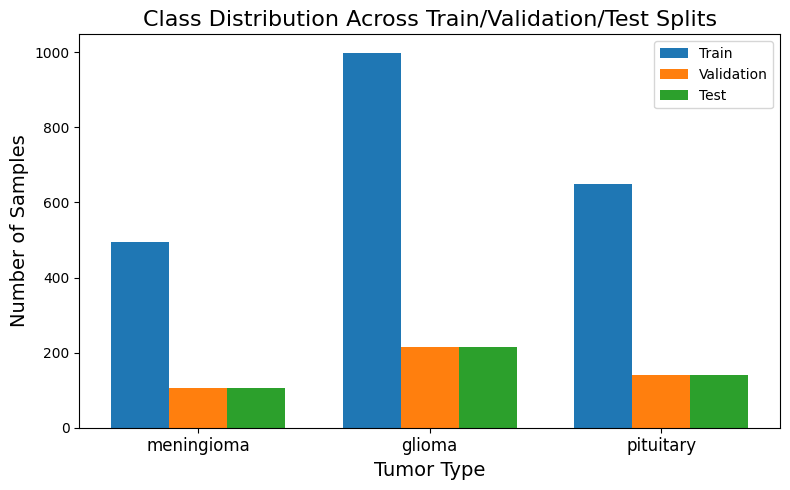

In [ ]:
import matplotlib.pyplot as plt

splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
tumor_classes = list(label_map.values())
bar_width = 0.25
x = range(len(tumor_classes))

plt.figure(figsize=(8,5))

# Plot bars for each split
for i, (split_name, df) in enumerate(splits.items()):
    counts = [df['tumor_type'].value_counts().get(c, 0) for c in tumor_classes]
    plt.bar([p + i*bar_width for p in x], counts, width=bar_width, label=split_name)

# Formatting
plt.xticks([p + bar_width for p in x], tumor_classes, fontsize=12)
plt.ylabel("Number of Samples", fontsize=14)
plt.xlabel("Tumor Type", fontsize=14)
plt.title("Class Distribution Across Train/Validation/Test Splits", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# ===============================
# Define dataset splits and target directories
# ===============================
splits = {
    'train': ('train_split.csv', './images_train'),
    'val':   ('val_split.csv',   './images_val'),
    'test':  ('test_split.csv',  './images_test'),
}

src_dir = './preprocessed_images'  # Source directory of preprocessed PNG images

# ===============================
# Copy images into split folders
# ===============================
for split_name, (csv_file, dst_dir) in splits.items():
    os.makedirs(dst_dir, exist_ok=True)
    df = pd.read_csv(csv_file)

    print(f"\nCopying {split_name} images to '{dst_dir}'...")
    missing_files = 0

    for fname in tqdm(df['filename'], desc=f"{split_name} images"):
        src_path = os.path.join(src_dir, f"{fname}.png")
        dst_path = os.path.join(dst_dir, f"{fname}.png")

        if os.path.exists(src_path):
            shutil.copyfile(src_path, dst_path)
        else:
            missing_files += 1
            print(f"  Warning: File not found: {src_path}")

    print(f"Completed {split_name} split. Missing files: {missing_files}")



Copying train images to './images_train'...


train images: 100%|██████████| 2144/2144 [00:01<00:00, 1642.25it/s]


Completed train split. Missing files: 0

Copying val images to './images_val'...


val images: 100%|██████████| 460/460 [00:00<00:00, 2543.70it/s]


Completed val split. Missing files: 0

Copying test images to './images_test'...


test images: 100%|██████████| 460/460 [00:00<00:00, 1237.29it/s]

Completed test split. Missing files: 0


In [ ]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# ===============================
# Define dataset splits and target directories
# ===============================
splits = {
    'train': ('train_split.csv', './images_train', './masks_train'),
    'val':   ('val_split.csv',   './images_val',   './masks_val'),
    'test':  ('test_split.csv',  './images_test',  './masks_test'),
}

img_src_dir = './preprocessed_images'  # Source folder for preprocessed MRI images
mask_src_dir = './preprocessed_masks'  # Source folder for preprocessed tumor masks

# ===============================
# Copy images and masks into split folders
# ===============================
for split_name, (csv_file, img_dst_dir, mask_dst_dir) in splits.items():
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(mask_dst_dir, exist_ok=True)

    df = pd.read_csv(csv_file)

    print(f"\nProcessing {split_name} split...")
    missing_images = 0
    missing_masks = 0

    for fname in tqdm(df['filename'], desc=f"{split_name} files"):
        # Image
        img_src_path = os.path.join(img_src_dir, f"{fname}.png")
        img_dst_path = os.path.join(img_dst_dir, f"{fname}.png")
        if os.path.exists(img_src_path):
            shutil.copyfile(img_src_path, img_dst_path)
        else:
            missing_images += 1
            print(f"  Warning: Image not found: {img_src_path}")

        # Mask
        mask_src_path = os.path.join(mask_src_dir, f"{fname}.npy")
        mask_dst_path = os.path.join(mask_dst_dir, f"{fname}.npy")
        if os.path.exists(mask_src_path):
            shutil.copyfile(mask_src_path, mask_dst_path)
        else:
            missing_masks += 1
            print(f"  Warning: Mask not found: {mask_src_path}")

    print(f"Completed {split_name} split. Missing images: {missing_images}, missing masks: {missing_masks}")



Processing train split...


train files: 100%|██████████| 2144/2144 [00:02<00:00, 975.82it/s]


Completed train split. Missing images: 0, missing masks: 0

Processing val split...


val files: 100%|██████████| 460/460 [00:00<00:00, 1035.50it/s]


Completed val split. Missing images: 0, missing masks: 0

Processing test split...


test files: 100%|██████████| 460/460 [00:00<00:00, 619.84it/s]

Completed test split. Missing images: 0, missing masks: 0


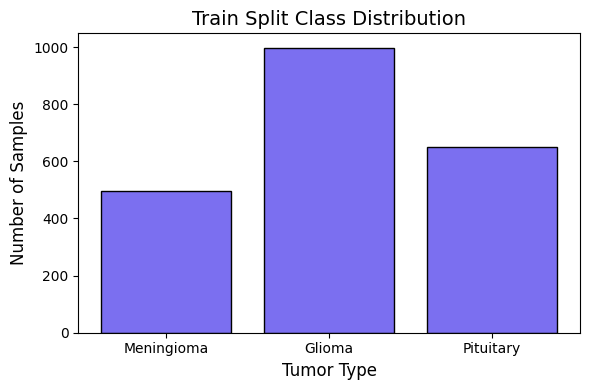

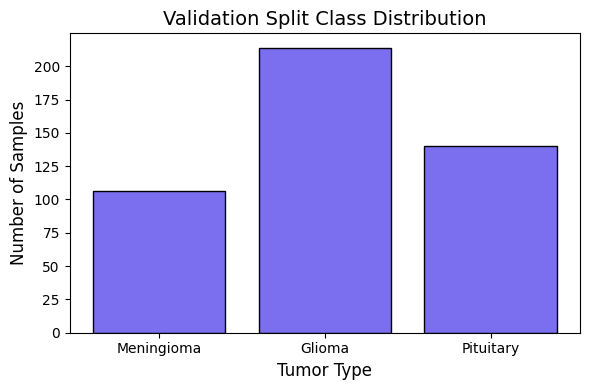

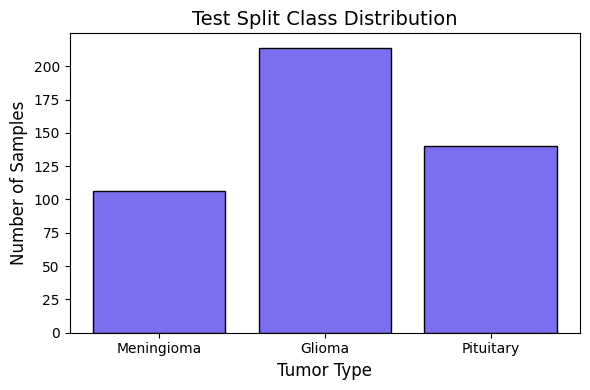

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]

for name, df in splits:
    # Count samples per class
    class_counts = Counter(df['label'])
    classes_sorted = sorted(class_counts)
    counts_sorted = [class_counts[k] for k in classes_sorted]

    # Plot bar chart
    plt.figure(figsize=(6,4))
    plt.bar([label_map[k].capitalize() for k in classes_sorted], counts_sorted, color='#7B6FF0', edgecolor='black')
    plt.xlabel("Tumor Type", fontsize=12)
    plt.ylabel("Number of Samples", fontsize=12)
    plt.title(f"{name} Split Class Distribution", fontsize=14)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
